<a href="https://colab.research.google.com/github/syakiraocta/ML-Fruit-Classification-VGG16/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np
import os

# Memastikan GPU aktif di Google Colab
print("Versi TensorFlow:", tf.__version__)
if tf.config.list_physical_devices('GPU'):
    print("GPU Tersedia (Training akan berjalan cepat!).")
else:
    print("GPU TIDAK Tersedia (Pastikan ganti runtime ke GPU via menu Runtime -> Change runtime type).")

Versi TensorFlow: 2.20.0
GPU Tersedia (Training akan berjalan cepat!).


In [2]:
from google.colab import drive

# Mengaktifkan koneksi ke Google Drive
print("Silakan setujui pop-up yang muncul untuk memberikan izin akses ke Google Drive...")
drive.mount('/content/drive')

print("Google Drive sukses terhubung!")

Silakan setujui pop-up yang muncul untuk memberikan izin akses ke Google Drive...
Mounted at /content/drive
Google Drive sukses terhubung!


In [3]:
# 1. Konfigurasi Augmentasi Gambar (Manipulasi Otomatis)
train_gen = ImageDataGenerator(
    rescale=1./255,        # Normalisasi nilai warna pixel ke rentang 0-1
    rotation_range=20,     # Memutar gambar otomatis
    zoom_range=0.2,        # Zoom-in / zoom-out otomatis
    horizontal_flip=True   # Membalik gambar secara horizontal
)

valid_gen = ImageDataGenerator(rescale=1./255)

# 2. JALUR BERTUMPUK (Menembak ke folder paling dalam sesuai struktur Drive kamu)
base_path = '/content/drive/MyDrive/Pembelajaran Mesin/Repo3/DatasetRepo3'
path_train = os.path.join(base_path, 'dataset/dataset/train')
path_test  = os.path.join(base_path, 'dataset/dataset/test')

# 3. Memuat Gambar dari Google Drive ke dalam Sistem Training
print("Sedang memuat data buah dari folder terdalam, mohon tunggu...")
train_it = train_gen.flow_from_directory(
    path_train,
    target_size=(224, 224), # Menyesuaikan ukuran input standar model VGG16
    batch_size=32,
    class_mode='categorical'
)

valid_it = valid_gen.flow_from_directory(
    path_test,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

print("\nSukses! Kategori kelas buah yang ditemukan:", train_it.class_indices)

Sedang memuat data buah dari folder terdalam, mohon tunggu...
Found 10902 images belonging to 6 classes.
Found 2699 images belonging to 6 classes.

Sukses! Kategori kelas buah yang ditemukan: {'freshapples': 0, 'freshbanana': 1, 'freshoranges': 2, 'rottenapples': 3, 'rottenbanana': 4, 'rottenoranges': 5}


In [4]:
# Load base model VGG16 raksasa tanpa lapisan klasifikasi teratasnya
base_model = keras.applications.VGG16(
    weights='imagenet',
    input_shape=(224, 224, 3),
    include_top=False
)

# Kunci lapisan dasar VGG16 agar tidak berubah saat proses belajar
base_model.trainable = False

# Menyusun lapisan klasifikasi baru di atas VGG16
inputs = keras.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = keras.layers.GlobalAveragePooling2D()(x) # Meratakan dimensi gambar

# Otomatis menyesuaikan jumlah output dengan jumlah kelas buah yang terdeteksi di Cell 3
num_classes = len(train_it.class_indices)
outputs = keras.layers.Dense(num_classes, activation='softmax')(x)

model = keras.Model(inputs, outputs)
model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │         3,078 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,717,766 (56.14 MB)

 Trainable params: 3,078 (12.02 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [5]:
# Kompilasi model dengan optimizer Adam dan loss categorical_crossentropy
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Memulai proses training model menggunakan GPU Colab...")
history = model.fit(
    train_it,
    steps_per_epoch=train_it.samples // train_it.batch_size,
    validation_data=valid_it,
    validation_steps=valid_it.samples // valid_it.batch_size,
    epochs=5
)

Memulai proses training model menggunakan GPU Colab...
Epoch 1/5
340/340 ━━━━━━━━━━━━━━━━━━━━ 4138s 12s/step - accuracy: 0.6283 - loss: 1.2341 - val_accuracy: 0.7444 - val_loss: 0.8721
Epoch 2/5
  1/340 ━━━━━━━━━━━━━━━━━━━━ 57s 168ms/step - accuracy: 0.6562 - loss: 0.8544

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


340/340 ━━━━━━━━━━━━━━━━━━━━ 25s 72ms/step - accuracy: 0.6562 - loss: 0.8544 - val_accuracy: 0.7500 - val_loss: 0.8684
Epoch 3/5
340/340 ━━━━━━━━━━━━━━━━━━━━ 230s 677ms/step - accuracy: 0.8117 - loss: 0.7740 - val_accuracy: 0.8516 - val_loss: 0.6219
Epoch 4/5
340/340 ━━━━━━━━━━━━━━━━━━━━ 21s 62ms/step - accuracy: 0.7812 - loss: 0.7751 - val_accuracy: 0.8519 - val_loss: 0.6213
Epoch 5/5
340/340 ━━━━━━━━━━━━━━━━━━━━ 235s 690ms/step - accuracy: 0.8468 - loss: 0.6076 - val_accuracy: 0.8713 - val_loss: 0.5071


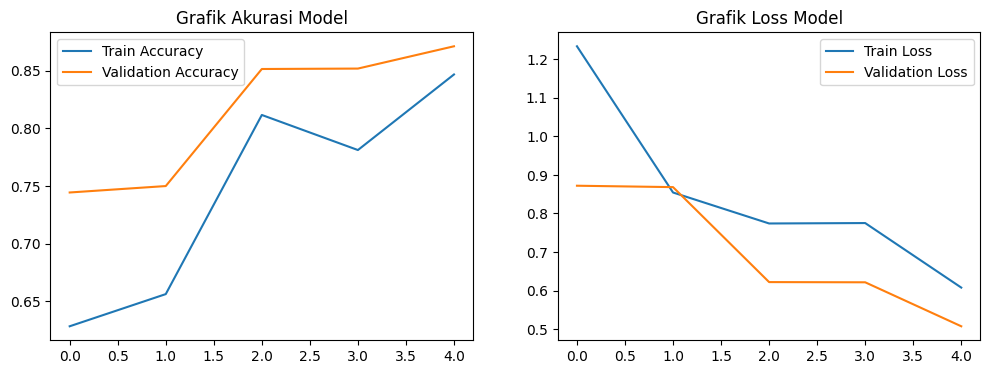

In [6]:

# 1. Menampilkan Grafik Akurasi dan Loss Hasil Pelatihan
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Grafik Akurasi Model')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Grafik Loss Model')
plt.legend()
plt.show()

# 2. Fungsi untuk menguji coba prediksi gambar buah baru
def prediksi_buah_baru(image_path):
    img = keras.preprocessing.image.load_img(image_path, target_size=(224, 224))
    img_array = keras.preprocessing.image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)
    classes = list(train_it.class_indices.keys())
    hasil_prediksi = classes[np.argmax(prediction)]

    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Hasil Analisis Model: {hasil_prediksi}")
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


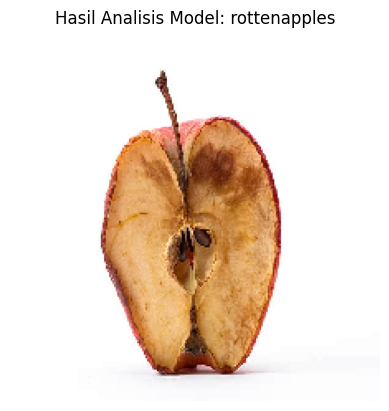

In [9]:
prediksi_buah_baru('/content/test_buah.jpg')